# Dental Index Prediction - DINOv2 End-to-End Fine-Tuning

This notebook trains a robust multi-view model for MGI, OHI, and GEI using DINOv2 with partial backbone fine-tuning, strong augmentation, AMP, and 5-fold cross-validation.

## 1. Setup
Training is optimized for a high-end GPU with TF32, cuDNN benchmarking, AMP, and gradient accumulation.

In [1]:
import os, sys, gc, json, time, random, warnings, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
else:
    torch.set_num_threads(os.cpu_count() or 4)

try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    PROJECT_ROOT = Path.cwd()
    if (PROJECT_ROOT / 'Train_Model.ipynb').exists() and not (PROJECT_ROOT / 'Thesis_Data').exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'Thesis_Data').exists():
    PROJECT_ROOT = Path(r'E:\Dental_Project')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml.dataset import DentalDataset
from ml.model import DINOv2MultiViewModel, load_model
from ml.transforms import get_train_transforms, get_val_transforms

warnings.filterwarnings('ignore', category=UserWarning)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'Project root: {PROJECT_ROOT}')
print(f'Device: {device}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name} | VRAM: {props.total_mem / 1024**3:.1f} GB')
    print(f'AMP: {USE_AMP} | TF32: {torch.backends.cuda.matmul.allow_tf32}')

c:\Mugdh Sharma\CodeSpace\Dental_Score_analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Mugdh Sharma\CodeSpace\Dental_Score_analysis
Device: cpu


In [2]:
CONFIG = {
    'data_dir': str(PROJECT_ROOT / 'Thesis_Data'),
    'output_dir': str(PROJECT_ROOT / 'ml' / 'checkpoints'),
    'seed': 42,
    'image_size': 518,
    'n_folds': 5,
    'warmup_epochs': 15,
    'finetune_epochs': 40,
    'batch_size': 3,
    'accumulation_steps': 4,
    'head_lr': 1e-3,
    'ft_head_lr': 5e-4,
    'ft_backbone_lr': 2e-5,
    'weight_decay': 1e-2,
    'patience': 12,
    'dropout': 0.35,
    'unfreeze_blocks': 4,
    'label_smoothing': 0.1,
    'grad_clip': 1.0,
    'num_workers': 4,
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

for key, value in CONFIG.items():
    print(f'{key:20s}: {value}')
print(f'Effective batch size: {CONFIG["batch_size"] * CONFIG["accumulation_steps"]}')

data_dir            : c:\Mugdh Sharma\CodeSpace\Dental_Score_analysis\Thesis_Data
output_dir          : c:\Mugdh Sharma\CodeSpace\Dental_Score_analysis\ml\checkpoints
seed                : 42
image_size          : 518
n_folds             : 5
warmup_epochs       : 15
finetune_epochs     : 40
batch_size          : 3
accumulation_steps  : 4
head_lr             : 0.001
ft_head_lr          : 0.0005
ft_backbone_lr      : 2e-05
weight_decay        : 0.01
patience            : 12
dropout             : 0.35
unfreeze_blocks     : 4
label_smoothing     : 0.1
grad_clip           : 1.0
num_workers         : 4
Effective batch size: 12


## 2. Dataset Audit
This confirms the CSV labels and complete 3-view image availability used for training.

Loaded 201 complete samples from 203 entries
Complete samples: 201
MGI distribution: {0: 74, 1: 47, 2: 44, 3: 28, 4: 8}
OHI distribution: {0: 132, 1: 59, 2: 8, 3: 2}
GEI distribution: {0: 171, 1: 26, 2: 4}


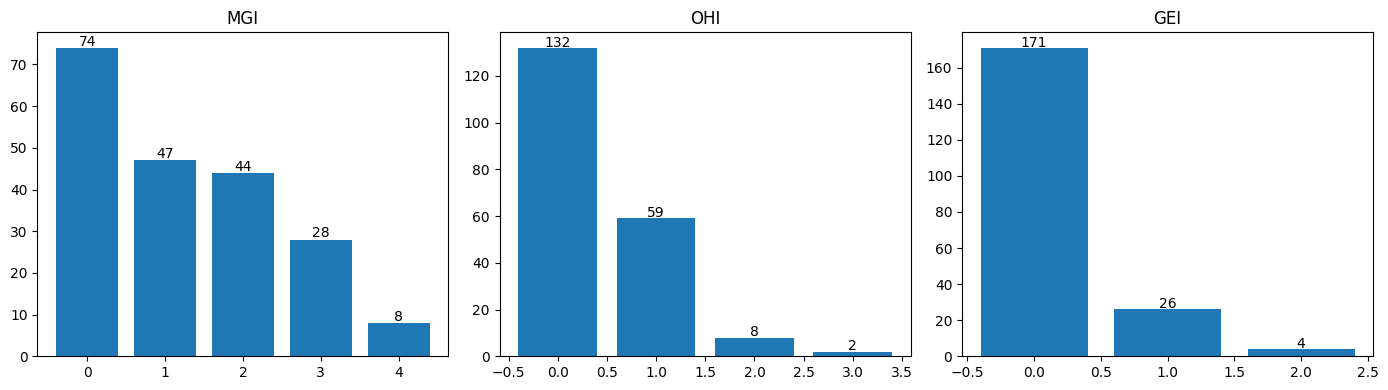

In [3]:
audit_dataset = DentalDataset(CONFIG['data_dir'], transform=get_val_transforms(CONFIG['image_size']))
all_ids = np.array([s['sl_no'] for s in audit_dataset.samples])
all_mgi = np.array([s['mgi'] for s in audit_dataset.samples])
all_ohi = np.array([s['ohi'] for s in audit_dataset.samples])
all_gei = np.array([s['gei'] for s in audit_dataset.samples])

print(f'Complete samples: {len(audit_dataset)}')
print(f'MGI distribution: {dict(enumerate(np.bincount(all_mgi, minlength=5).tolist()))}')
print(f'OHI distribution: {dict(enumerate(np.bincount(all_ohi, minlength=4).tolist()))}')
print(f'GEI distribution: {dict(enumerate(np.bincount(all_gei, minlength=3).tolist()))}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, dist, title in zip(axes, [np.bincount(all_mgi, minlength=5), np.bincount(all_ohi, minlength=4), np.bincount(all_gei, minlength=3)], ['MGI', 'OHI', 'GEI']):
    bars = ax.bar(range(len(dist)), dist)
    ax.set_title(title)
    for bar, val in zip(bars, dist):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(int(val)), ha='center')
plt.tight_layout()
plt.show()

In [4]:
def compute_class_weights(labels, n_classes):
    counts = np.bincount(labels, minlength=n_classes).astype(float) + 1e-6
    weights = 1.0 / counts
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32, device=device)

mgi_weights = compute_class_weights(all_mgi, 5)
ohi_weights = compute_class_weights(all_ohi, 4)
gei_weights = compute_class_weights(all_gei, 3)

class MultiTaskCELoss(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.mgi_loss = nn.CrossEntropyLoss(weight=mgi_weights, label_smoothing=smoothing)
        self.ohi_loss = nn.CrossEntropyLoss(weight=ohi_weights, label_smoothing=smoothing)
        self.gei_loss = nn.CrossEntropyLoss(weight=gei_weights, label_smoothing=smoothing)

    def forward(self, outputs, mgi, ohi, gei):
        return self.mgi_loss(outputs['mgi'], mgi) + self.ohi_loss(outputs['ohi'], ohi) + self.gei_loss(outputs['gei'], gei)

criterion = MultiTaskCELoss(CONFIG['label_smoothing'])
print('Loss and class weights ready')

Loss and class weights ready


## 3. Training Functions
Phase 1 trains only the classifier head. Phase 2 unfreezes the last backbone blocks and fine-tunes with a much lower backbone learning rate.

In [5]:
def build_loaders(train_ids, val_ids):
    train_ds = DentalDataset(CONFIG['data_dir'], transform=get_train_transforms(CONFIG['image_size']), patient_ids=set(train_ids.tolist()))
    val_ds = DentalDataset(CONFIG['data_dir'], transform=get_val_transforms(CONFIG['image_size']), patient_ids=set(val_ids.tolist()))
    loader_kwargs = dict(
        num_workers=CONFIG['num_workers'],
        pin_memory=torch.cuda.is_available(),
        persistent_workers=CONFIG['num_workers'] > 0,
    )
    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True, **loader_kwargs)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, **loader_kwargs)
    return train_ds, val_ds, train_loader, val_loader

def run_epoch(model, loader, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train(is_train)
    loss_sum = 0.0
    count = 0
    preds = {'mgi': [], 'ohi': [], 'gei': []}
    trues = {'mgi': [], 'ohi': [], 'gei': []}
    if is_train:
        optimizer.zero_grad(set_to_none=True)
    for step, batch in enumerate(loader):
        frontal = batch['frontal'].to(device, non_blocking=True)
        left = batch['left_lateral'].to(device, non_blocking=True)
        right = batch['right_lateral'].to(device, non_blocking=True)
        mgi = batch['mgi_label'].to(device, non_blocking=True)
        ohi = batch['ohi_label'].to(device, non_blocking=True)
        gei = batch['gei_label'].to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            outputs = model(frontal, left, right)
            loss = criterion(outputs, mgi, ohi, gei)
        bs = frontal.size(0)
        loss_sum += loss.item() * bs
        count += bs
        if is_train:
            scaler.scale(loss / CONFIG['accumulation_steps']).backward()
            if (step + 1) % CONFIG['accumulation_steps'] == 0 or (step + 1) == len(loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], CONFIG['grad_clip'])
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
        else:
            for key, lbl in [('mgi', mgi), ('ohi', ohi), ('gei', gei)]:
                preds[key].extend(outputs[key].argmax(1).cpu().tolist())
                trues[key].extend(lbl.cpu().tolist())
    avg_loss = loss_sum / max(count, 1)
    accs = None if is_train else {k: accuracy_score(trues[k], preds[k]) for k in preds}
    return avg_loss, accs, preds, trues

def train_one_fold(fold_idx, train_ids, val_ids):
    train_ds, val_ds, train_loader, val_loader = build_loaders(train_ids, val_ids)
    model = DINOv2MultiViewModel(dropout=CONFIG['dropout'], pretrained_backbone=True, img_size=CONFIG['image_size'], unfreeze_blocks=0).to(device)
    history = []
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=CONFIG['head_lr'], weight_decay=CONFIG['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['warmup_epochs'], eta_min=1e-5)
    for epoch in range(1, CONFIG['warmup_epochs'] + 1):
        tr_loss, _, _, _ = run_epoch(model, train_loader, optimizer, scaler)
        vl_loss, accs, _, _ = run_epoch(model, val_loader)
        scheduler.step()
        history.append({'epoch': epoch, 'phase': 1, 'train_loss': tr_loss, 'val_loss': vl_loss, 'accs': accs, 'avg_acc': float(np.mean(list(accs.values())))})

    model._configure_backbone_freezing(CONFIG['unfreeze_blocks'])
    optimizer = torch.optim.AdamW(model.get_param_groups(CONFIG['ft_backbone_lr'], CONFIG['ft_head_lr'], CONFIG['weight_decay']))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['finetune_epochs'], eta_min=1e-7)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    best_state = None
    best_loss = float('inf')
    patience = 0
    for epoch in range(1, CONFIG['finetune_epochs'] + 1):
        tr_loss, _, _, _ = run_epoch(model, train_loader, optimizer, scaler)
        vl_loss, accs, preds, trues = run_epoch(model, val_loader)
        scheduler.step()
        full_epoch = CONFIG['warmup_epochs'] + epoch
        history.append({'epoch': full_epoch, 'phase': 2, 'train_loss': tr_loss, 'val_loss': vl_loss, 'accs': accs, 'avg_acc': float(np.mean(list(accs.values())))})
        if vl_loss < best_loss:
            best_loss = vl_loss
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
        if patience >= CONFIG['patience']:
            break

    model.load_state_dict(best_state)
    _, accs, preds, trues = run_epoch(model, val_loader)
    val_order = [sample['sl_no'] for sample in val_ds.samples]
    return model, best_loss, accs, preds, trues, val_order, history

print('Training functions ready')

Training functions ready


## 4. Cross-Validation Training
This is the main training cell. It saves full fold checkpoints and one best-model fallback checkpoint for Django.

In [ ]:
skf = StratifiedKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=CONFIG['seed'])
fold_accs = []
fold_val_losses = []
all_histories = []
oof_preds = {'mgi': {}, 'ohi': {}, 'gei': {}}
oof_trues = {'mgi': {}, 'ohi': {}, 'gei': {}}

for fold, (train_idx, val_idx) in enumerate(skf.split(np.arange(len(all_mgi)), all_mgi), 1):
    print(f'Fold {fold}/{CONFIG["n_folds"]}')
    model, val_loss, accs, preds, trues, val_order, history = train_one_fold(fold, all_ids[train_idx], all_ids[val_idx])
    fold_accs.append(accs)
    fold_val_losses.append(val_loss)
    all_histories.append(history)
    for idx, sl_no in enumerate(val_order):
        for key in ['mgi', 'ohi', 'gei']:
            oof_preds[key][sl_no] = preds[key][idx]
            oof_trues[key][sl_no] = trues[key][idx]
    torch.save({
        'model_state_dict': model.state_dict(),
        'head_state_dict': model.classifier.state_dict(),
        'fold': fold,
        'val_loss': val_loss,
        'accs': accs,
        'config': CONFIG,
    }, os.path.join(CONFIG['output_dir'], f'fold_{fold}_head.pth'))
    model.cpu()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

best_fold = int(np.argmin(fold_val_losses)) + 1
import shutil
shutil.copy(os.path.join(CONFIG['output_dir'], f'fold_{best_fold}_head.pth'), os.path.join(CONFIG['output_dir'], 'best_model.pth'))
print(f'Best fold: {best_fold}')

Fold 1/5
Loaded 160 complete samples from 203 entries
Loaded 41 complete samples from 203 entries


## 5. Evaluation
Out-of-fold evaluation is the correct reliability estimate here because each patient is predicted only on a fold where it was held out.

In [ ]:
oof_pred_arr = {k: np.array([oof_preds[k].get(sid, -1) for sid in all_ids]) for k in ['mgi', 'ohi', 'gei']}
oof_true_arr = {k: np.array([oof_trues[k].get(sid, -1) for sid in all_ids]) for k in ['mgi', 'ohi', 'gei']}
valid_mask = oof_pred_arr['mgi'] >= 0
oof_accs = {k: accuracy_score(oof_true_arr[k][valid_mask], oof_pred_arr[k][valid_mask]) for k in ['mgi', 'ohi', 'gei']}
print(oof_accs)
for key, n_cls, name in [('mgi', 5, 'MGI'), ('ohi', 4, 'OHI'), ('gei', 3, 'GEI')]:
    print(f'\n{name}')
    print(classification_report(oof_true_arr[key][valid_mask], oof_pred_arr[key][valid_mask], labels=list(range(n_cls)), zero_division=0))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, key, n_cls, name in zip(axes, ['mgi', 'ohi', 'gei'], [5, 4, 3], ['MGI', 'OHI', 'GEI']):
    cm = confusion_matrix(oof_true_arr[key][valid_mask], oof_pred_arr[key][valid_mask], labels=list(range(n_cls)))
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} | OOF {oof_accs[key]:.1%}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(n_cls):
        for j in range(n_cls):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, CONFIG['n_folds'], figsize=(4 * CONFIG['n_folds'], 4), squeeze=False)
for fold_idx in range(CONFIG['n_folds']):
    ax = axes[0, fold_idx]
    hist = all_histories[fold_idx]
    epochs = [row['epoch'] for row in hist]
    ax.plot(epochs, [row['train_loss'] for row in hist], label='Train')
    ax.plot(epochs, [row['val_loss'] for row in hist], label='Val')
    ax.axvline(CONFIG['warmup_epochs'], color='green', linestyle=':')
    ax.set_title(f'Fold {fold_idx + 1}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Save Metadata
This saves ensemble metadata and training history used by the Django app and for later analysis.

In [ ]:
ensemble_info = {
    'n_folds': CONFIG['n_folds'],
    'backbone': 'vit_base_patch14_reg4_dinov2',
    'feature_dim': 768,
    'image_size': CONFIG['image_size'],
    'fold_accs': {idx: fold_accs[idx] for idx in range(len(fold_accs))},
    'oof_accs': oof_accs,
    'config': CONFIG,
}
torch.save(ensemble_info, os.path.join(CONFIG['output_dir'], 'ensemble_info.pth'))
with open(os.path.join(CONFIG['output_dir'], 'training_history.json'), 'w') as f:
    json.dump({'fold_accs': fold_accs, 'oof_accs': oof_accs, 'all_histories': all_histories, 'config': CONFIG}, f, indent=2, default=str)
print('Saved ensemble_info.pth and training_history.json')

## 7. Inference Smoke Test
This validates that the saved checkpoints load through the same path used by Django inference.

In [ ]:
model = load_model(os.path.join(CONFIG['output_dir'], 'best_model.pth'), device)
model.eval()
sample = audit_dataset.samples[0]
tfm = get_val_transforms(CONFIG['image_size'])
from PIL import Image
inputs = {
    'frontal': tfm(Image.open(sample['frontal']).convert('RGB')).unsqueeze(0).to(device),
    'left_lateral': tfm(Image.open(sample['left_lateral']).convert('RGB')).unsqueeze(0).to(device),
    'right_lateral': tfm(Image.open(sample['right_lateral']).convert('RGB')).unsqueeze(0).to(device),
}
with torch.no_grad():
    pred = model.predict_scores(inputs['frontal'], inputs['left_lateral'], inputs['right_lateral'])
for key in ['mgi', 'ohi', 'gei']:
    print(key, pred[key]['score'].item(), f'{pred[key]["confidence"].item():.0f}%')

## Notes
- This notebook uses end-to-end fine-tuning rather than cached features.
- The strongest practical next gain would be patient-safe external validation or expert relabeling for borderline OHI/GEI cases.
- TTA is already enabled in runtime inference through [ml/inference.py](ml/inference.py).